# Scripts de extracción de datos
- Osvaldo Ceballos O. , Andrés Jimenez B.

In [44]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

import os
cwd= os.getcwd()
print (cwd)

/content


## 1.- Fuentes típicas internacionales

### 1.1.- Kaggle

In [ ]:
!pip install kaggle

In [ ]:
!chmod 600 /root/.config/kaggle/kaggle.json

In [ ]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

# Configurar y autenticar
api = KaggleApi()
api.authenticate()

# Especificar el dataset y la ruta de destino
dataset = 'nokkyu/deutsche-bahn-db-delays'  #@param
path = './datasets/'  #@param

# Descargar dataset
api.dataset_download_files(dataset, path=path, unzip=True)

Dataset URL: https://www.kaggle.com/datasets/nokkyu/deutsche-bahn-db-delays


In [ ]:
import pandas as pd

# Ruta al archivo CSV descargado
csv_file = './datasets/DBtrainrides.csv'#@param

# Importar el CSV a un DataFrame de Pandas
df_deutche_trains_delays = pd.read_csv(csv_file)

# Mostrar las primeras filas del DataFrame
df_deutche_trains_delays = pd.read_csv(csv_file)
df_deutche_trains_delays.head()

,ID,line,path,eva_nr,category,station,state,city,zip,long,lat,arrival_plan,departure_plan,arrival_change,departure_change,arrival_delay_m,departure_delay_m,info,arrival_delay_check,departure_delay_check
0,1573967790757085557-2407072312-14,20,Stolberg(Rheinl)Hbf Gl.44|Eschweiler-St.Jöris|...,8000001,2,Aachen Hbf,Nordrhein-Westfalen,Aachen,52064,6.091499,50.767800,2024-07-08 00:00:00,2024-07-08 00:01:00,2024-07-08 00:03:00,2024-07-08 00:04:00,3,3,NaN,on_time,on_time
1,349781417030375472-2407080017-1,18,NaN,8000001,2,Aachen Hbf,Nordrhein-Westfalen,Aachen,52064,6.091499,50.767800,NaN,2024-07-08 00:17:00,NaN,NaN,0,0,NaN,on_time,on_time
2,7157250219775883918-2407072120-25,1,Hamm(Westf)Hbf|Kamen|Kamen-Methler|Dortmund-Ku...,8000406,4,Aachen-Rothe Erde,Nordrhein-Westfalen,Aachen,52066,6.116475,50.770202,2024-07-08 00:03:00,2024-07-08 00:04:00,2024-07-08 00:03:00,2024-07-08 00:04:00,0,0,NaN,on_time,on_time
3,349781417030375472-2407080017-2,18,Aachen Hbf,8000404,5,Aachen West,Nordrhein-Westfalen,Aachen,52072,6.070715,50.780360,2024-07-08 00:20:00,2024-07-08 00:21:00,NaN,NaN,0,0,NaN,on_time,on_time
4,1983158592123451570-2407080010-3,33,Herzogenrath|Kohlscheid,8000404,5,Aachen West,Nordrhein-Westfalen,Aachen,52072,6.070715,50.780360,2024-07-08 00:20:00,2024-07-08 00:21:00,2024-07-08 00:20:00,2024-07-08 00:21:00,0,0,NaN,on_time,on_time


### 1.2 UCI Machine Learning Repository

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

#id repo
id_repo = 45 #@param

# fetch dataset
heart_disease = fetch_ucirepo(id=id_repo)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

heart_disease_df = pd.concat([X,y], axis=1)

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M. Pfisterer, J. Schmid, S. Sa

In [ ]:
#dataset
heart_disease_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


### 1.3 Google Reseach Datasets

In [55]:
# Install the required packages
!pip install google-cloud-storage

In [56]:
#### @title Imports

import collections
import copy
import hashlib
import io
import os
import subprocess
import textwrap
import time

from typing import List, Text

from PIL import Image

import numpy as np
import pandas as pd
import tabulate

In [58]:
from google.colab import auth

# Authenticate user for access. There will be a popup asking you to sign in with your user and approve access.
auth.authenticate_user()

In [59]:
###@title Global params

class Globals:
  # GCP project with GCS bucket of interest
  gcp_project = 'dx-scin-public' #@param

  # GCS bucket with data to read
  gcs_bucket_name = 'dx-scin-public-data' #@param

  # CSV of case metadata to read
  cases_csv = 'dataset/scin_cases.csv' #@param

  # CSV of label metadata to read
  labels_csv = 'dataset/scin_labels.csv' #@param

  # Images directory
  gcs_images_dir = 'dataset/images/' #@param

  ### Key column names
  image_path_columns = ['image_1_path', 'image_2_path', 'image_3_path']
  weighted_skin_condition_label = "weighted_skin_condition_label"
  skin_condition_label = "dermatologist_skin_condition_on_label_name"

  ###### Formed during execution:

  # Client for querying GCS
  gcs_storage_client = None

  # Bucket object for loading files
  gcs_bucket = None

  # pd.DataFrame for the loaded metadata_csv
  cases_df = None

  # pd.DataFrame for the loaded labels_csv
  cases_and_labels_df = None

print(f'GCS bucket name: {Globals.gcs_bucket_name}')
print(f'cases_csv: {Globals.cases_csv}')
print(f'labels_csv: {Globals.labels_csv}')
print(f'images dir: {Globals.gcs_images_dir}')


GCS bucket name: dx-scin-public-data
cases_csv: dataset/scin_cases.csv
labels_csv: dataset/scin_labels.csv
images dir: dataset/images/


In [60]:
### @title Create a dataframe that contains the metadata and condition labels

from google.cloud import storage

def list_blobs(storage_client, bucket_name):
  """Helper to list blobs in a bucket (useful for debugging)."""
  blobs = storage_client.list_blobs(bucket_name)
  for blob in blobs:
    print(blob)

def initialize_df_with_metadata(bucket, csv_path):
  """Loads the given CSV into a pd.DataFrame."""
  df = pd.read_csv(io.BytesIO(bucket.blob(csv_path).download_as_string()), dtype={'case_id': str})
  df['case_id'] = df['case_id'].astype(str)
  return df

def augment_metadata_with_labels(df, bucket, csv_path):
  """Loads the given CSV into a pd.DataFrame."""
  labels_df = pd.read_csv(io.BytesIO(bucket.blob(csv_path).download_as_string()), dtype={'case_id': str})
  labels_df['case_id'] = labels_df['case_id'].astype(str)
  merged_df = pd.merge(df, labels_df, on='case_id')
  return merged_df

Globals.gcs_storage_client = storage.Client(Globals.gcp_project)
Globals.gcs_bucket = Globals.gcs_storage_client.bucket(
    Globals.gcs_bucket_name
)
Globals.cases_df = initialize_df_with_metadata(Globals.gcs_bucket, Globals.cases_csv)
Globals.cases_and_labels_df = augment_metadata_with_labels(Globals.cases_df, Globals.gcs_bucket, Globals.labels_csv)
print(len(Globals.cases_and_labels_df))

5033


In [61]:
Globals.cases_and_labels_df.columns

Index(['case_id', 'source', 'release', 'year', 'age_group', 'sex_at_birth',
       'fitzpatrick_skin_type',
       'race_ethnicity_american_indian_or_alaska_native',
       'race_ethnicity_asian', 'race_ethnicity_black_or_african_american',
       'race_ethnicity_hispanic_latino_or_spanish_origin',
       'race_ethnicity_middle_eastern_or_north_african',
       'race_ethnicity_native_hawaiian_or_pacific_islander',
       'race_ethnicity_white', 'race_ethnicity_other_race',
       'race_ethnicity_prefer_not_to_answer', 'textures_raised_or_bumpy',
       'textures_flat', 'textures_rough_or_flaky', 'textures_fluid_filled',
       'body_parts_head_or_neck', 'body_parts_arm', 'body_parts_palm',
       'body_parts_back_of_hand', 'body_parts_torso_front',
       'body_parts_torso_back', 'body_parts_genitalia_or_groin',
       'body_parts_buttocks', 'body_parts_leg', 'body_parts_foot_top_or_side',
       'body_parts_foot_sole', 'body_parts_other',
       'condition_symptoms_bothersome_appearan

In [62]:
Globals.cases_and_labels_df.head()

,case_id,source,release,year,age_group,sex_at_birth,fitzpatrick_skin_type,race_ethnicity_american_indian_or_alaska_native,race_ethnicity_asian,race_ethnicity_black_or_african_american,race_ethnicity_hispanic_latino_or_spanish_origin,race_ethnicity_middle_eastern_or_north_african,race_ethnicity_native_hawaiian_or_pacific_islander,race_ethnicity_white,race_ethnicity_other_race,race_ethnicity_prefer_not_to_answer,textures_raised_or_bumpy,textures_flat,textures_rough_or_flaky,textures_fluid_filled,body_parts_head_or_neck,body_parts_arm,body_parts_palm,body_parts_back_of_hand,body_parts_torso_front,body_parts_torso_back,body_parts_genitalia_or_groin,body_parts_buttocks,body_parts_leg,body_parts_foot_top_or_side,body_parts_foot_sole,body_parts_other,condition_symptoms_bothersome_appearance,condition_symptoms_bleeding,condition_symptoms_increasing_size,condition_symptoms_darkening,condition_symptoms_itching,condition_symptoms_burning,condition_symptoms_pain,condition_symptoms_no_relevant_experience,other_symptoms_fever,other_symptoms_chills,other_symptoms_fatigue,other_symptoms_joint_pain,other_symptoms_mouth_sores,other_symptoms_shortness_of_breath,other_symptoms_no_relevant_symptoms,related_category,condition_duration,image_1_path,image_2_path,image_3_path,image_1_shot_type,image_2_shot_type,image_3_shot_type,combined_race,race_ethnicity_two_or_more_after_mitigation,dermatologist_gradable_for_skin_condition_1,dermatologist_gradable_for_skin_condition_2,dermatologist_gradable_for_skin_condition_3,dermatologist_skin_condition_on_label_name,dermatologist_skin_condition_confidence,weighted_skin_condition_label,dermatologist_gradable_for_fitzpatrick_skin_type_1,dermatologist_gradable_for_fitzpatrick_skin_type_2,dermatologist_gradable_for_fitzpatrick_skin_type_3,dermatologist_fitzpatrick_skin_type_label_1,dermatologist_fitzpatrick_skin_type_label_2,dermatologist_fitzpatrick_skin_type_label_3,gradable_for_monk_skin_tone_india,gradable_for_monk_skin_tone_us,monk_skin_tone_label_india,monk_skin_tone_label_us
0,-1000600354148496558,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN,NaN,NaN,YES,YES,NaN,YES,YES,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,RASH,ONE_DAY,dataset/images/-3205742176803893704.png,NaN,NaN,CLOSE_UP,NaN,NaN,NaN,NaN,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Inflicted skin lesions', 'Eczema', 'Irritant...","[4, 4, 3]","{'Inflicted skin lesions': 0.41, 'Eczema': 0.4...",YES,NaN,NaN,FST2,NaN,NaN,True,True,2.0,1.0
1,-1002039107727665188,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dataset/images/-4762289084741430925.png,NaN,NaN,CLOSE_UP,NaN,NaN,NaN,NaN,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Prurigo nodularis', 'Actinic Keratosis', 'SC...","[4, 3, 4]","{'Prurigo nodularis': 0.41, 'SCC/SCCIS': 0.41,...",YES,NaN,NaN,FST1,NaN,NaN,True,True,3.0,3.0
2,-1003358831658393077,SCIN,1.0.0,2023,AGE_18_TO_29,MALE,NONE_IDENTIFIED,NaN,NaN,NaN,YES,NaN,NaN,NaN,NaN,NaN,NaN,YES,YES,NaN,NaN,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN,YES,YES,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,OTHER_ISSUE_DESCRIPTION,ONE_TO_FOUR_WEEKS,dataset/images/-4027806997035329030.png,NaN,NaN,CLOSE_UP,NaN,NaN,HISPANIC_LATINO_OR_SPANISH_ORIGIN,NaN,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Impetigo', 'Herpes Zoster', 'Bullous dermati...","[2, 1, 1]","{'Impetigo': 0.55, 'Herpes Zoster': 0.23, 'Bul...",YES,NaN,NaN,FST4,NaN,NaN,True,True,3.0,4.0
3,-1003826561155964328,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN,YES,NaN,NaN,NaN,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,YES,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,OTHER_ISSUE_DESCRIPTION,ONE_DAY,dataset/images/-5332065579713135540.png,dataset/images/-63534317080649697

In [84]:
Globals.cases_and_labels_df[Globals.image_path_columns].values.tolist()[0]

['dataset/images/-3205742176803893704.png', nan, nan]

1


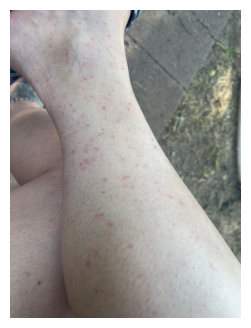

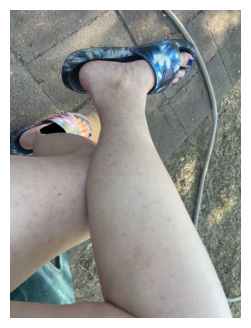

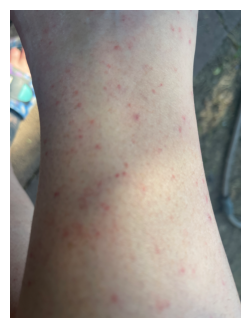

{'Lichen planus/lichenoid eruption': 0.33, 'Folliculitis': 0.33, 'Dermatosis due to flea': 0.33}


In [83]:
#@title Display the images for a case (and condition labels, optionally)
import random

import io
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def display_image(bucket, image_path):
  image = Image.open(io.BytesIO(bucket.blob(image_path).download_as_string()))
  figure_size=4
  f, axarr = plt.subplots(1, 1, figsize = (figure_size, figure_size))
  axarr.imshow(image, cmap='gray')
  axarr.axis('off')
  plt.show()

def display_images_for_case(df, case_id="", print_condition_labels=True):
  # Use a random case if none is provided:
  if case_id:
    matched_df = df[df['case_id'] == case_id]
    print(matched_df.shape[0])
  else:
    matched_df = df.sample(1)

  image_paths = matched_df[Globals.image_path_columns].values.tolist()[0]
  for path in image_paths:
    if isinstance(path, str):
      display_image(Globals.gcs_bucket, path)
  if print_condition_labels:
    condition_labels = matched_df[[Globals.weighted_skin_condition_label]].values.tolist()[0]
    for label in condition_labels:
      if isinstance(label, str):
        print(label)

display_images_for_case(Globals.cases_and_labels_df, case_id="-1003844406100696311")

## 2.- Fuentes típicas nacionales

### 2.1 Datos Abiertos Gobierno de Chile (Datos.gov.cl)

In [ ]:
!pip install ckanapi requests openpyxl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 834.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.9/137.9 kB 2.5 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13704 sha256=4d102a7596afa01f13414b76f05b116d88848e52d8c95bc2147b95069747fb39
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt


In [ ]:
import urllib
from ckanapi import RemoteCKAN

In [ ]:
# URL del portal CKAN
ckan_url = 'https://datos.gob.cl/'

# Conexión al portal CKAN
ckan = RemoteCKAN(ckan_url)

# Realizar una búsqueda de datasets
query = 'parques'  #@param
results = ckan.action.package_search(q=query)

# Mostrar nombres y descripciones de los primeros datasets encontrados
for dataset in results['results']:
    print(f"Nombre: {dataset['title']}")
    print(f"Descripción: {dataset['notes']}")
    print(f"Id: {dataset['id']}\n")

Nombre: Listado Plazas, Áreas verdes, Parques  Sector Centro
Descripción: Listado Plazas, Áreas verdes, Parques  Sector Centro
Id: ccb5c078-d950-48f4-900b-d7fa4be21b07

Nombre: Listado Plazas, Áreas verdes, Parques  Sector Oriente
Descripción: Listado Plazas, Áreas verdes, Parques  Sector Oriente
Id: 4a714c44-87a9-4469-ae03-703116a1fbd6

Nombre: Listado Plazas, Áreas verdes, Parques  Sector Sur
Descripción: Listado Plazas, Áreas verdes, Parques  Sector Sur
Id: 93299587-ac22-4c40-a1d9-6af44f0b80a1

Nombre: Listado Plazas, Áreas verdes, Parques Sector Norte
Descripción: Listado Plazas, Áreas verdes, Parques Sector Norte
Id: eec68726-877a-4642-b73c-e55bdb560066

Nombre: Número y Metros Cuadrados de Parques y Plazas
Descripción: Número y Superficie de Parque y Plazas por Comuna, 2011.
Id: 7bdd610f-4da3-40b4-98e9-34e34115db3a

Nombre: Número y Metros Cuadrados de Parques y Plazas
Descripción: Número y Superficie de Parque y Plazas por Comuna, 2011.
Id: cc6f65cb-10f2-449b-8f6d-86c0cb77ca92



In [ ]:
dataset_id = 'ccb5c078-d950-48f4-900b-d7fa4be21b07'  #@param

# Obtener detalles del dataset
dataset = ckan.action.package_show(id=dataset_id)

# Mostrar información relevante
print(f"Nombre: {dataset['title']}")
print(f"Descripción: {dataset['notes']}")
print(f"Recursos disponibles:")

for resource in dataset['resources']:
    print(f"- {resource['name']}: {resource['format']} ({resource['url']})")

Nombre: Listado Plazas, Áreas verdes, Parques  Sector Centro
Descripción: Listado Plazas, Áreas verdes, Parques  Sector Centro
Recursos disponibles:
- Listado Sector Centro: .xlsx (https://datos.gob.cl/dataset/ccb5c078-d950-48f4-900b-d7fa4be21b07/resource/1d7ec097-9727-410f-a2ea-da7622d95b85/download/listado-sector-centro.xlsx)


In [ ]:
# URL del recurso CSV
csv_url = 'https://datos.gob.cl/dataset/ccb5c078-d950-48f4-900b-d7fa4be21b07/resource/1d7ec097-9727-410f-a2ea-da7622d95b85/download/listado-sector-centro.xlsx'  #@param

# Descargar y cargar en un DataFrame de Pandas
parques_centro_df = pd.read_excel(csv_url)

# Mostrar las primeras filas del DataFrame
parques_centro_df.head()

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,N°,AREA VERDES,UBICACIÓN,m2
0,1.0,EL COIGUE DE MAGALLANES,EL COIGUE DE MAGALLANES / VILLA JARDINES DE ...,1541.0
1,2.0,PARQUE LA VIÑA DE LO CAÑAS,ROJAS MAGALLANES / AV. S. FONTECILLA / EL H...,8847.0
2,3.0,EL COIGUE DE CHILOE,CALLE EL C. DE CHILOE - VILLA LOS JARDINES D...,1661.0
3,4.0,PARQUE DE LA VIÑA,LAS ARAUCARIAS SUR / LAS NALCAS SUR,7938.0
4,5.0,ARRAYAN ROJO,LAS ARAUCARIAS SUR,868.0


### 2.2 Banco Central de Chile

In [ ]:
!pip install bcchapi

In [ ]:
import bcchapi

# Incluyendo credenciales explícitamente
# O bien llamando a un archivo
#siete = bcchapi.Siete(file="credenciales.txt")

In [ ]:
siete.buscar("M1")

,seriesId,frequencyCode,spanishTitle,englishTitle,firstObservation,lastObservation,updatedAt,createdAt
0,F021.M1.PRO.N.CLP.0.M,MONTHLY,"Agregados monetarios nominales saldos, M1 (Mil...","Balances nominal monetary aggregates, M1",1986-01-01,2024-07-01,2024-08-07,2024-08-07
1,F021.M1.PRO.N.CLP.1.M,MONTHLY,"Agregados monetarios nominales saldos, M1 dese...","Balances nominal monetary aggregates, M1 seaso...",1986-01-01,2024-07-01,2024-08-07,2024-08-07
2,F021.M1.STO.N.CLP.0.M,MONTHLY,"M1; agregados monetarios nominales, promedios ...","M1; nominal monetary aggregates, averaged (bil...",1965-12-01,2024-07-01,2024-08-07,2024-08-07
3,F021.M1.STO.N.CLP.HIST.M,MONTHLY,"Agregados monetarios nominales promedios, M1, ...",Base monetaria y agregados monetarios privados...,1965-12-01,2014-12-01,2015-05-28,2015-02-09
4,F021.M1.STO.R.P96.0.M,MONTHLY,"Agregados monetarios promedios reales , M1","Average real monetary aggregates, M1",1986-01-01,2023-12-01,2024-01-08,2024-01-08
5,F021.M1.STO.R.P96.1.M,MONTHLY,"Agregados monetarios promedios reales , M1 des...","Average real monetary aggregates, seasonally a...",1986-01-01,2023-12-01,2024-01-08,2024-01-08
6,F021.M1.STO.R.P96R23.0.M,MONTHLY,"M1 : Stock : Real : Pesos del 1996, referencia...","M1: Stock: Real: 1996 pesos, reference 2023: N...",1986-01-01,2024-07-01,2024-08-08,2024-08-08
7,F021.M1.STO.R.P96R23.1.M,MONTHLY,"M1 : Stock : Real : Pesos del 1996, referencia...","M1: Stock: Real: 1996 pesos, reference 2023: S...",1986-01-01,2024-07-01,2024-08-08,2024-08-08
8,F021.M1.STO.N.CLP.0.D,DAILY,Base monetaria y agregados monetarios privados...,Components of M1 (billions of pesos). M1,2011-01-03,2024-07-31,2024-08-07,2024-08-07
9,F021.M1.STS.N.CLP.0.D,DAILY,Base monetaria y agregados monetarios privados...,Base monetaria y agregados monetarios privados...,1996-01-07,2024-08-07,2024-08-16,2024-08-16


In [ ]:
series_bc = siete.cuadro(
  series=["F032.IMC.IND.Z.Z.EP18.Z.Z.0.M", "G073.IPC.IND.2018.M","F021.M1.STO.N.CLP.0.M"],
  nombres = ["imacec", "ipc","M1"],
  desde="2010-01-01",
  hasta="2024-07-01",
  #variacion=12,
  frecuencia="M",
  observado={"imacec":"mean", "ipc":"last", "M1":"mean"}
)

In [ ]:
series_bc = series_bc.fillna(0)
series_bc.head(50)

,imacec,ipc,M1
2010-01-31,72.478647,76.458780,13780.600000
2010-02-28,69.784256,76.673627,13876.100000
2010-03-31,75.714061,76.738097,14204.700000
2010-04-30,77.836154,77.092780,14333.800000
2010-05-31,77.265080,77.370183,15026.700000
2010-06-30,76.186444,77.370465,15322.400000
2010-07-31,74.112635,77.867485,15145.300000
2010-08-31,77.296543,77.790935,15125.600000
2010-09-30,75.050155,78.102046,15648.800000
2010-10-31,80.061679,78.178624,15449.000000


### 2.3 API de Chilecompra A.K.A Mercado Público

In [6]:
import requests
import pandas as pd

In [2]:
def obtener_json_desde_url(url):
  # Realizar la solicitud GET
  response = requests.get(url)

  # Verificar si la solicitud fue exitosa (código 200)
  if response.status_code == 200:
      # Convertir la respuesta a un diccionario/lista de Python
      data = response.json()
      return data
  else:
      print(f"Error al obtener los datos: {response.status_code}")
      return None

In [51]:
api_token ="tu token" #@param

In [49]:
url_organismos_publicos = f"https://api.mercadopublico.cl/servicios/v1/Publico/Empresas/BuscarComprador?ticket={api_token}"

data_organismos_publicos = obtener_json_desde_url(url_organismos_publicos)

df_organismos_publicos = pd.DataFrame(data_organismos_publicos['listaEmpresas'])


In [24]:
df_organismos_publicos.head(10)

,CodigoEmpresa,NombreEmpresa
0,7086,AGENCIA CHILENA DE COOPERACION INTERNACIONAL P...
1,1224636,AGENCIA CHILENA DE EFICIENCIA ENERGETICA
2,7193,AGENCIA DE PROMOCION DE LA INVERSION EXTRANJERA
3,7212,Agencia Nacional de Inteligencia
4,1824441,ASOCIACION DE MUNICIPIOS METROPOLITANOS PARA L...
5,1806837,Asociación para el desarrollo productivo del t...
6,6959,Banco del Estado de Chile
7,7265,Biblioteca del Congreso Nacional
8,7038,Bienestar del Registro Civil
9,7313,C.D.T. Doctora Eloisa Díaz


In [25]:
df_organismos_publicos[df_organismos_publicos['NombreEmpresa']=='I MUNICIPALIDAD DE VITACURA']

,CodigoEmpresa,NombreEmpresa
536,98462,I MUNICIPALIDAD DE VITACURA


In [52]:
url_agencia_coop_int = f"https://api.mercadopublico.cl/servicios/v1/publico/licitaciones.json?estado=adjudicada&ticket={api_token}"

data_agencia_coop_int = obtener_json_desde_url(url_agencia_coop_int)
print(data_agencia_coop_int)

{'Cantidad': 0, 'FechaCreacion': '2026-03-11T00:30:06.1254063-03:00', 'Version': 'v1', 'Listado': []}


In [31]:
df_licitaciones_adjudicadas = pd.DataFrame(data_agencia_coop_int['Listado'])
df_licitaciones_adjudicadas.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre
0,2183-12-LR25,Servicio de Aseo e Insumos en Edificios Unidad...,8,2025-11-12T17:00:00
1,1510-4-LE26,SERVICIO DE ASEO INTEGRAL LIMPIEZA Y DESINFECCIÓN,8,2026-03-09T15:00:00
2,740-4-LE26,CONTRATACIÓN DE LOS SERVICIOS DE FERIA EXPO ARROZ,8,2026-02-25T15:30:00
3,1237853-6-LE26,Adquisición de artículos deportivos,8,2026-03-05T19:52:00
4,1134432-15-LE26,“CONTRATACIÓN DE SERVICIO DE ESTERILIZACIONES ...,8,2026-03-03T19:55:00


In [53]:
url_licitacion_especifica = f"https://api.mercadopublico.cl/servicios/v1/publico/licitaciones.json?codigo=1237853-6-LE26&ticket={api_token}"

data_licitacion = obtener_json_desde_url(url_licitacion_especifica)

licitacion_df = pd.json_normalize(data_licitacion['Listado'])

In [54]:
display(licitacion_df)

,CodigoExterno,Nombre,CodigoEstado,Descripcion,FechaCierre,Estado,DiasCierreLicitacion,Informada,CodigoTipo,Tipo,TipoConvocatoria,Moneda,Etapas,EstadoEtapas,TomaRazon,EstadoPublicidadOfertas,JustificacionPublicidad,Contrato,Obras,CantidadReclamos,UnidadTiempoEvaluacion,DireccionVisita,DireccionEntrega,Estimacion,FuenteFinanciamiento,VisibilidadMonto,MontoEstimado,Tiempo,UnidadTiempo,Modalidad,TipoPago,NombreResponsablePago,EmailResponsablePago,NombreResponsableContrato,EmailResponsableContrato,FonoResponsableContrato,ProhibicionContratacion,SubContratacion,UnidadTiempoDuracionContrato,TiempoDuracionContrato,TipoDuracionContrato,JustificacionMontoEstimado,ObservacionContract,ExtensionPlazo,EsBaseTipo,UnidadTiempoContratoLicitacion,ValorTiempoRenovacion,PeriodoTiempoRenovacion,EsRenovable,CodigoBIP,Comprador.CodigoOrganismo,Comprador.NombreOrganismo,Comprador.RutUnidad,Comprador.CodigoUnidad,Comprador.NombreUnidad,Comprador.DireccionUnidad,Comprador.ComunaUnidad,Comprador.RegionUnidad,Comprador.RutUsuario,Comprador.CodigoUsuario,Comprador.NombreUsuario,Comprador.CargoUsuario,Fechas.FechaCreacion,Fechas.FechaCierre,Fechas.FechaInicio,Fechas.FechaFinal,Fechas.FechaPubRespuestas,Fechas.FechaActoAperturaTecnica,Fechas.FechaActoAperturaEconomica,Fechas.FechaPublicacion,Fechas.FechaAdjudicacion,Fechas.FechaEstimadaAdjudicacion,Fechas.FechaSoporteFisico,Fechas.FechaTiempoEvaluacion,Fechas.FechaEstimadaFirma,Fechas.FechasUsuario,Fechas.FechaVisitaTerreno,Fechas.FechaEntregaAntecedentes,Adjudicacion.Tipo,Adjudicacion.Fecha,Adjudicacion.Numero,Adjudicacion.NumeroOferentes,Adjudicacion.UrlActa,Items.Cantidad,Items.Listado
0,1237853-6-LE26,Adquisición de artículos deportivos,8,Adquirir implementos necesarios para el desarr...,None,Adjudicada,0,0,1,LE,1,CLP,1,1,0,1,,2,0,0,1,,,1,,0,None,None,1,1,1,Maximiliano Avilés,,Patricio Zarricueta,,,Según bases adjuntas,0,1,0,,,None,0,0,1,0,,0,None,1824117,CORPORACION DEL DEPORTE DE LA FLORIDA,65.320.930-4,1237853,CORPORACION DEL DEPORTE DE LA FLORIDA,Enrique Olivares 1003,La Florida,Región Metropolitana de Santiago,,1918982,PATRICIO ZARRICUETA VERGARA,Administrador,2026-02-27T16:15:08.117,2026-03-05T19:52:00,2026-02-27T20:19:00,2026-03-02T20:19:00,2026-03-03T20:19:00,2026-03-05T19:53:00,2026-03-05T19:53:00,2026-02-27T16:44:13.707,2026-03-10T19:19:02.373,2026-03-10T19:53:00,None,None,None,None,None,None,2,2026-03-10T00:00:00,46,11,http://www.mercadopublico.cl/Procurement/Modul...,1,"[{'Correlativo': 1, 'CodigoProducto': 49221511..."


## 3.- Crear tus propias fuentes

### 3.1 WebScraping

In [85]:
!pip install requests beautifulsoup4

In [89]:
import requests
from bs4 import BeautifulSoup

# URL de la página web que deseas analizar
url = 'https://portaleduca.cl/ranking-colegios-2024-los-100-mejores-promedios-paes/' #@param

# Hacer una solicitud GET a la página web
response = requests.get(url)

# Verificar que la solicitud fue exitosa
if response.status_code == 200:
    soup = BeautifulSoup(response.content, 'html.parser')
    table = soup.find('table', attrs={'width': '738'})

    if table is None:
        print("No se encontró ninguna tabla en la página web.")
    else:
        headers = []
        rows = []

        # Extraer los encabezados de la tabla
        for th in table.find_all('th'):
            headers.append(th.get_text().strip())

        if len(headers)==0:
            headers = ['Lugar', 'Establecimiento', 'Tipo', 'Comuna', 'Rinden', 'Pruebas']

        # Extraer las filas de la tabla
        for tr in table.find_all('tr'):
            cells = tr.find_all('td')
            if len(cells) > 0:
                row = [cell.get_text().strip() for cell in cells]
                rows.append(row)

        # Comprobar si todas las filas tienen el mismo número de columnas
        for row in rows:
            if len(row) != len(headers):
                print(f"Advertencia: la fila tiene {len(row)} columnas, pero los encabezados tienen {len(headers)} columnas.")
                print(f"Fila: {row}")

        # Crear el DataFrame
        if len(headers) == 0:
            print("No se encontraron encabezados de tabla.")
        elif len(rows) > 0:
            df = pd.DataFrame(rows, columns=headers)
            df.head()
        else:
            print("No se encontraron filas de datos en la tabla.")
else:
    print(f"Error al acceder a la página: {response.status_code}")

In [92]:
df

,Lugar,Establecimiento,Tipo,Comuna,Rinden,Pruebas
0,Lugar,Establecimiento,Tipo,Comuna,Rinden,Pruebas
1,1,Cambridge College,P. Pagado,Providencia,28,"879,3"
2,2,Tabancura,P. Pagado,Vitacura,107,"864,7"
3,3,Los Alerces,P. Pagado,Lo Barnechea,65,"860,4"
4,4,Lincoln International Academy,P. Pagado,Lo Barnechea,26,"852,9"
5,5,The Grande School,P. Pagado,La Reina,126,848
6,6,Cordillera,P. Pagado,Las Condes,67,"845,9"
7,7,Arauco,P. Pagado,Arauco,16,"845,4"
8,8,Villa María Academy,P. Pagado,Las Condes,118,"843,1"
9,9,Huinganal,P. Pagado,Lo Barnechea,27,"842,9"
